# 犬と猫の分類

ライブラリの読み込み

In [1]:
# TensorFlow と tf.keras のインポート
import tensorflow as tf
from tensorflow import keras

# ヘルパーライブラリのインポート
import numpy as np
import matplotlib.pyplot as plt
import os

# TensorBoard用
%load_ext tensorboard
print(tf.__version__)

# データ用作成用
import pandas as pd
import shutil

2.5.0


# １．データの準備

データのダウンロード

In [2]:
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!tar -xzvf images.tar.gz

ストリーミング出力は最後の 5000 行に切り捨てられました。
images/american_bulldog_194.jpg
images/Birman_175.jpg
images/american_bulldog_178.jpg
images/staffordshire_bull_terrier_93.jpg
images/Egyptian_Mau_58.jpg
images/havanese_44.jpg
images/english_cocker_spaniel_97.jpg
images/Ragdoll_111.jpg
images/american_pit_bull_terrier_159.jpg
images/english_setter_134.jpg
images/english_setter_87.jpg
images/wheaten_terrier_198.jpg
images/pug_180.jpg
images/boxer_172.jpg
images/Sphynx_197.jpg
images/german_shorthaired_2.jpg
images/British_Shorthair_9.jpg
images/pug_89.jpg
images/japanese_chin_39.jpg
images/Ragdoll_20.jpg
images/american_bulldog_111.jpg
images/yorkshire_terrier_112.jpg
images/Persian_88.jpg
images/pug_9.jpg
images/Birman_40.jpg
images/British_Shorthair_272.jpg
images/havanese_7.jpg
images/pomeranian_154.jpg
images/beagle_49.jpg
images/British_Shorthair_94.jpg
images/Persian_90.jpg
images/staffordshire_bull_terrier_30.jpg
images/samoyed_113.jpg
images/english_cocker_spaniel_46.jpg
images/Abyssinian_22.jpg


分類ルールのダウンロード

In [3]:
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xzvf annotations.tar.gz

ストリーミング出力は最後の 5000 行に切り捨てられました。
annotations/trimaps/._pomeranian_180.png
annotations/trimaps/pomeranian_180.png
annotations/trimaps/._pomeranian_181.png
annotations/trimaps/pomeranian_181.png
annotations/trimaps/._pomeranian_182.png
annotations/trimaps/pomeranian_182.png
annotations/trimaps/._pomeranian_183.png
annotations/trimaps/pomeranian_183.png
annotations/trimaps/._pomeranian_184.png
annotations/trimaps/pomeranian_184.png
annotations/trimaps/._pomeranian_185.png
annotations/trimaps/pomeranian_185.png
annotations/trimaps/._pomeranian_186.png
annotations/trimaps/pomeranian_186.png
annotations/trimaps/._pomeranian_187.png
annotations/trimaps/pomeranian_187.png
annotations/trimaps/._pomeranian_188.png
annotations/trimaps/pomeranian_188.png
annotations/trimaps/._pomeranian_189.png
annotations/trimaps/pomeranian_189.png
annotations/trimaps/._pomeranian_19.png
annotations/trimaps/pomeranian_19.png
annotations/trimaps/._pomeranian_190.png
annotations/trimaps/pomeranian_190.png
annotation

学習データのディレクトリ作成

In [4]:
!mkdir -p train/cats
!mkdir -p train/dogs

学習データのファイル名の読み込み

In [5]:
df = pd.read_csv("annotations/trainval.txt", sep=" ", header=None,index_col=0)

犬と猫のディレクトリに分ける

In [6]:
for name,data in df.iterrows():
  if data[2]==1:
    shutil.copy('images/'+name+'.jpg', 'train/dogs/')
  else:
    shutil.copy('images/'+name+'.jpg', 'train/cats/')

検証データのディレクトリ作成

In [7]:
!mkdir -p validation/cats
!mkdir -p validation/dogs

検証データのファイル名の読み込み

In [8]:
df = pd.read_csv("annotations/test.txt", sep=" ", header=None,index_col=0)

犬と猫のディレクトリに分ける

In [9]:
for name,data in df.iterrows():
  if data[2]==1:
    shutil.copy('images/'+name+'.jpg', 'validation/dogs/')
  else:
    shutil.copy('images/'+name+'.jpg', 'validation/cats/')

データの情報の設定と表示（ディレクトリと画像枚数）

In [10]:
train_dir = os.path.join('.', 'train')
validation_dir = os.path.join('.', 'validation')

train_cats_dir = os.path.join(train_dir, 'cats')  # 学習用の猫画像のディレクトリ
train_dogs_dir = os.path.join(train_dir, 'dogs')  # 学習用の犬画像のディレクトリ
validation_cats_dir = os.path.join(validation_dir, 'cats')  # 検証用の猫画像のディレクトリ
validation_dogs_dir = os.path.join(validation_dir, 'dogs')  # 検証用の犬画像のディレクトリ

print('total training cat images:', len(os.listdir(train_cats_dir)))#犬の訓練データの数
print('total training dog images:', len(os.listdir(train_dogs_dir)))#犬の検証データの数
print('total validation cat images:', len(os.listdir(validation_cats_dir)))#ネコの訓練データの数
print('total validation dog images:', len(os.listdir(validation_dogs_dir)))#ネコの検証データの数

total training cat images: 2492
total training dog images: 1188
total validation cat images: 2486
total validation dog images: 1183


画像変換の設定

In [11]:
batch_size = 128
IMG_HEIGHT = 150
IMG_WIDTH = 150

In [12]:
train_image_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255) # 学習データのジェネレータ
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                           directory=train_dir,
                                                           shuffle=True,
                                                           target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                           class_mode='binary')

Found 3680 images belonging to 2 classes.


In [13]:
validation_image_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255) # 検証データのジェネレータ
val_data_gen = validation_image_generator.flow_from_directory(batch_size=batch_size,
                                                              directory=validation_dir,
                                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              class_mode='binary')

Found 3669 images belonging to 2 classes.


画像情報の表示

In [14]:
print(train_data_gen.n)
print(train_data_gen.num_classes)
print(train_data_gen.labels)
print(train_data_gen.image_shape)
print(train_data_gen[0][0][0])


3680
2
[0 0 0 ... 1 1 1]
(150, 150, 3)
[[[0.16470589 0.19607845 0.20392159]
  [0.04313726 0.07450981 0.08235294]
  [0.03921569 0.05882353 0.07058824]
  ...
  [0.07843138 0.07450981 0.05882353]
  [0.09019608 0.07450981 0.0627451 ]
  [0.08627451 0.06666667 0.05490196]]

 [[0.16862746 0.21568629 0.21568629]
  [0.10196079 0.14117648 0.14901961]
  [0.07843138 0.11764707 0.12156864]
  ...
  [0.0627451  0.04705883 0.03529412]
  [0.0627451  0.04313726 0.03137255]
  [0.04313726 0.02745098 0.01568628]]

 [[0.19215688 0.23137257 0.23529413]
  [0.16862746 0.20784315 0.21568629]
  [0.13333334 0.16862746 0.16470589]
  ...
  [0.01568628 0.01176471 0.00392157]
  [0.02745098 0.01176471 0.00784314]
  [0.01960784 0.00392157 0.        ]]

 ...

 [[0.5058824  0.34509805 0.32156864]
  [0.7176471  0.69803923 0.5803922 ]
  [0.74509805 0.7176471  0.6431373 ]
  ...
  [0.76470596 0.76470596 0.76470596]
  [0.78823537 0.7725491  0.7607844 ]
  [0.86666673 0.86274517 0.8470589 ]]

 [[0.73333335 0.7019608  0.61960787

画像の表示

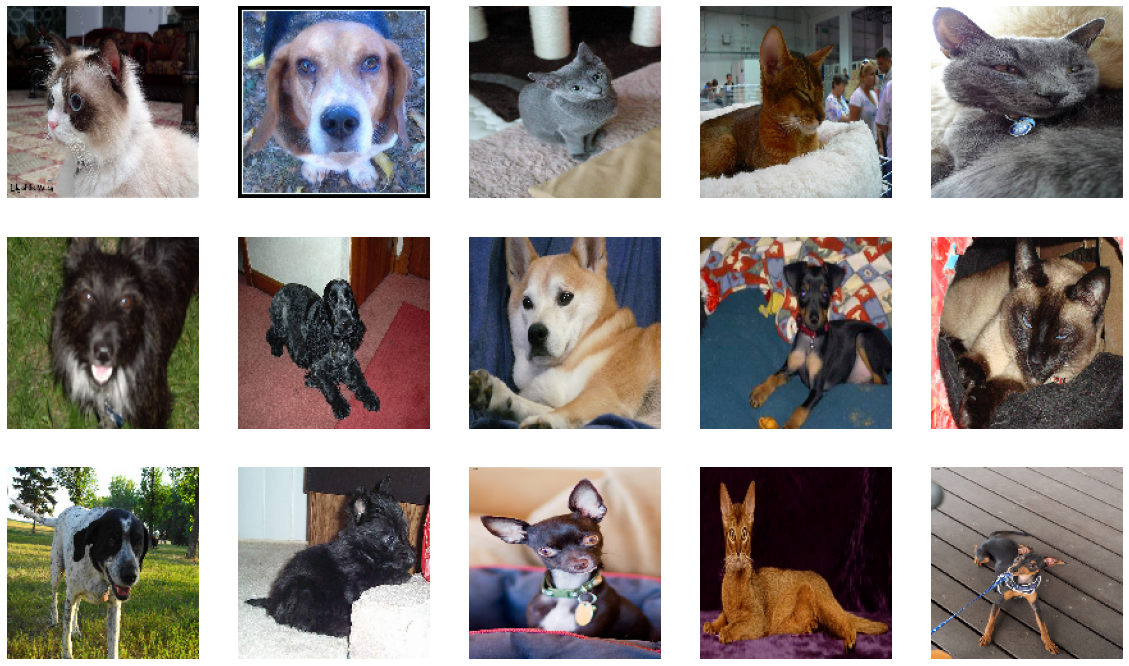

In [15]:
plt.figure(figsize=(20,12))
for i in range(15):
    plt.subplot(3,5,i+1)
    plt.axis('off')
    plt.imshow(train_data_gen[0][0][i])
plt.show()

# ２．学習

ネットワークの設定

In [16]:
model = keras.Sequential([
    keras.layers.Conv2D(16, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH ,3)),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

ネットワークの表示

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 150, 150, 16)      448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 75, 75, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 75, 75, 32)        4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 37, 37, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 37, 37, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 18, 18, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 20736)             0

学習の設定

In [18]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

エポック数の設定

In [19]:
epochs = 15

学習の開始

In [20]:
history = model.fit_generator(
    train_data_gen,
    steps_per_epoch=train_data_gen.n // batch_size,
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.n // batch_size
)

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/15
28/28 [==============================] - 64s 1s/step - loss: 0.6955 - accuracy: 0.6464 - val_loss: 0.6097 - val_accuracy: 0.6780
Epoch 2/15
28/28 [==============================] - 32s 1s/step - loss: 0.5932 - accuracy: 0.6830 - val_loss: 0.5494 - val_accuracy: 0.7277
Epoch 3/15
28/28 [==============================] - 31s 1s/step - loss: 0.5350 - accuracy: 0.7289 - val_loss: 0.5138 - val_accuracy: 0.7380
Epoch 4/15
28/28 [==============================] - 31s 1s/step - loss: 0.5020 - accuracy: 0.7523 - val_loss: 0.5216 - val_accuracy: 0.7408
Epoch 5/15
28/28 [==============================] - 32s 1s/step - loss: 0.4545 - accuracy: 0.7911 - val_loss: 0.4871 - val_accuracy: 0.7715
Epoch 6/15
28/28 [==============================] - 31s 1s/step - loss: 0.4421 - accuracy: 0.7998 - val_loss: 0.5471 - val_accuracy: 0.7335
Epoch 7/15
28/28 [==============================] - 31s 1s/step - loss: 0.3931 - accuracy: 0.8255 - val_loss: 0.5052 - val_accuracy: 0.7782
Epoch 8/15
28/28 [==

# ３．学習結果の表示

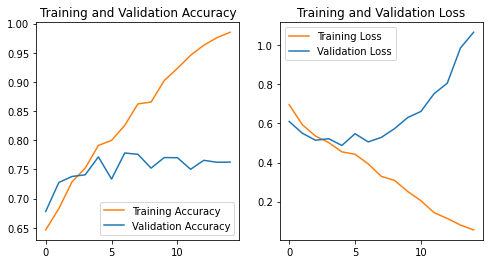

In [23]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', c='C1')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', c='C0')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', c='C1')
plt.plot(epochs_range, val_loss, label='Validation Loss', c='C0')
plt.legend(loc='upper left')
plt.title('Training and Validation Loss')
plt.show()

# ４．データ拡張

反転

In [24]:
image_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, horizontal_flip=True)
data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))

Found 3680 images belonging to 2 classes.


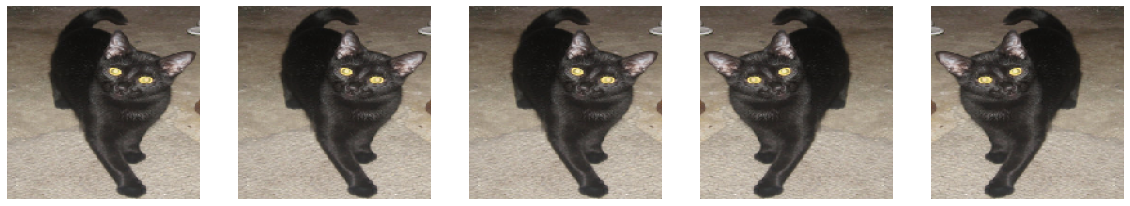

In [25]:
plt.figure(figsize=(20,20))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.axis('off')
    plt.imshow(data_gen[0][0][0])
plt.show()

回転

In [26]:
image_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, rotation_range=90)
data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))

Found 3680 images belonging to 2 classes.


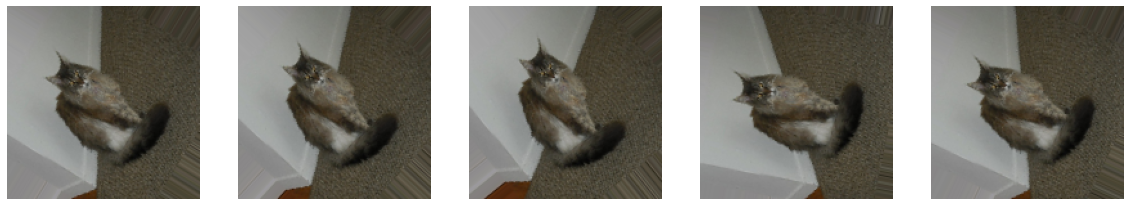

In [27]:
plt.figure(figsize=(20,20))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.axis('off')
    plt.imshow(data_gen[0][0][0])
plt.show()

平行移動

In [28]:
image_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, width_shift_range=0.15,height_shift_range=0.15)
data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))

Found 3680 images belonging to 2 classes.


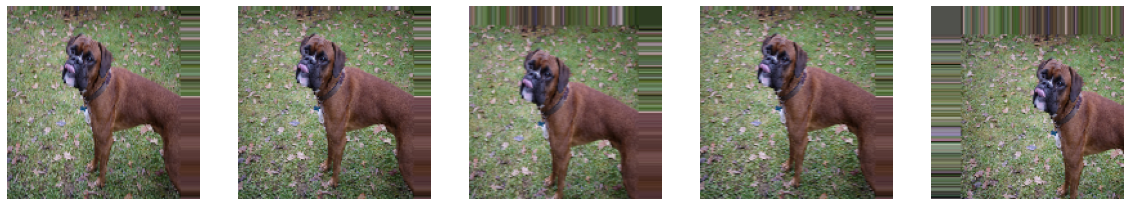

In [29]:
plt.figure(figsize=(20,20))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.axis('off')
    plt.imshow(data_gen[0][0][0])
plt.show()

拡大

In [30]:
image_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, zoom_range=0.5)
data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))

Found 3680 images belonging to 2 classes.


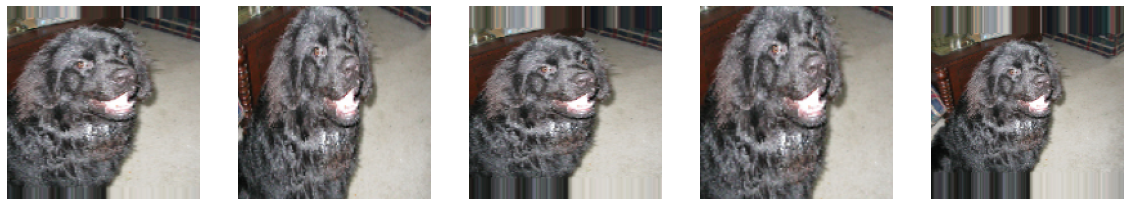

In [31]:
plt.figure(figsize=(20,20))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.axis('off')
    plt.imshow(data_gen[0][0][0])
plt.show()

4つの変換の組み合わせ

In [32]:
image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
                    rescale=1./255,
                    rotation_range=45,
                    width_shift_range=0.15,
                    height_shift_range=0.15,
                    horizontal_flip=True,
                    zoom_range=0.5
                    )
data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))

Found 3680 images belonging to 2 classes.


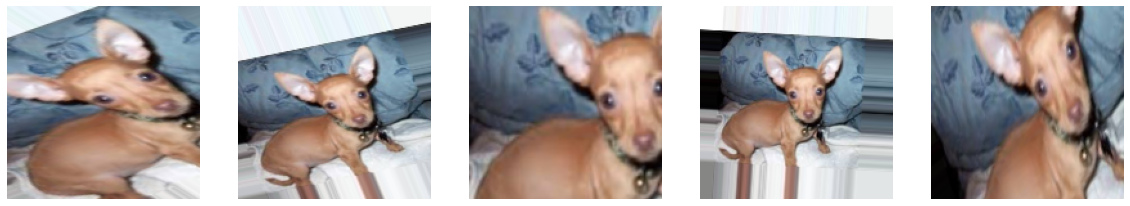

In [33]:
plt.figure(figsize=(20,20))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.axis('off')
    plt.imshow(data_gen[0][0][0])
plt.show()

In [34]:
train_image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
                    rescale=1./255,
                    rotation_range=45,
                    width_shift_range=0.15,
                    height_shift_range=0.15,
                    horizontal_flip=True,
                    zoom_range=0.5
                    )
train_data_gen = train_image_gen.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     shuffle=True,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

Found 3680 images belonging to 2 classes.


In [35]:
validation_image_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255) # 検証データのジェネレータ
val_data_gen = validation_image_generator.flow_from_directory(batch_size=batch_size,
                                                 directory=validation_dir,
                                                 target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                 class_mode='binary')

Found 3669 images belonging to 2 classes.


In [36]:
model_new = keras.Sequential([
    keras.layers.Conv2D(16, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH ,3)),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_new.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 150, 150, 16)      448       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 75, 75, 16)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 75, 75, 32)        4640      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 37, 37, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 37, 37, 64)        18496     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 18, 18, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 20736)            

In [37]:
model_new.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [38]:
epochs=100
history_new = model_new.fit_generator(
    train_data_gen,
    steps_per_epoch=train_data_gen.n // batch_size,
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.n // batch_size
)

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/100
28/28 [==============================] - 46s 2s/step - loss: 0.8539 - accuracy: 0.6425 - val_loss: 0.6314 - val_accuracy: 0.6761
Epoch 2/100
28/28 [==============================] - 45s 2s/step - loss: 0.6320 - accuracy: 0.6751 - val_loss: 0.6034 - val_accuracy: 0.6797
Epoch 3/100
28/28 [==============================] - 45s 2s/step - loss: 0.6156 - accuracy: 0.6768 - val_loss: 0.5822 - val_accuracy: 0.6881
Epoch 4/100
28/28 [==============================] - 45s 2s/step - loss: 0.5983 - accuracy: 0.6861 - val_loss: 0.6166 - val_accuracy: 0.6833
Epoch 5/100
28/28 [==============================] - 45s 2s/step - loss: 0.5970 - accuracy: 0.6861 - val_loss: 0.5733 - val_accuracy: 0.6883
Epoch 6/100
28/28 [==============================] - 45s 2s/step - loss: 0.6001 - accuracy: 0.6906 - val_loss: 0.5653 - val_accuracy: 0.6922
Epoch 7/100
28/28 [==============================] - 44s 2s/step - loss: 0.5854 - accuracy: 0.6889 - val_loss: 0.6454 - val_accuracy: 0.6900
Epoch 8/100
2

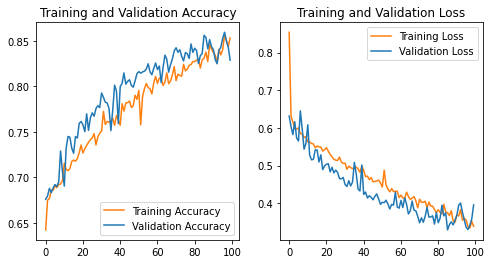

In [40]:
acc = history_new.history['accuracy']
val_acc = history_new.history['val_accuracy']

loss = history_new.history['loss']
val_loss = history_new.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', c='C1')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', c='C0')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', c='C1')
plt.plot(epochs_range, val_loss, label='Validation Loss', c='C0')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# ５．作成したデータで予測

画像の読み込み

In [ ]:
my_image_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255) # 学習データのジェネレータ
my_data_gen = my_image_generator.flow_from_directory(batch_size=batch_size,
                                                           directory='/content/test',
                                                           shuffle=False,
                                                           target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                           class_mode='binary')

Found 10 images belonging to 2 classes.


読み込んだ画像一覧

In [ ]:
print(my_data_gen.filenames)

['dc/Abyssinian_201.jpg', 'dc/Bengal_192.jpg', 'dc/Birman_191.jpg', 'dc/Bombay_200.jpg', 'dc/British_Shorthair_212.jpg', 'dc/american_bulldog_203.jpg', 'dc/american_pit_bull_terrier_191.jpg', 'dc/basset_hound_191.jpg', 'dc/beagle_195.jpg', 'dc/boxer_191.jpg']


分類

[[0.00454909]]
result= [[0.]]


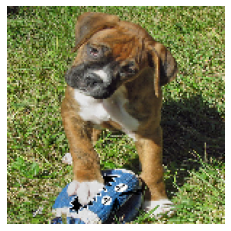

In [ ]:
i = 9#ここの番号を変更する
plt.axis('off')
plt.imshow(my_data_gen[0][0][i])
prediction = model_new.predict(my_data_gen[0][0][i].reshape(1, 150, 150, 3)) # モデルの推論
print(prediction)
print("result=",np.round(prediction))